In [1]:
import os
import logging
import numpy as np
import pandas as pd
import scipy.interpolate
import scipy.optimize
import scipy.spatial # For KDTree
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.interpolate import LinearNDInterpolator

# --- EOS Table Column Indices ---
# Assumes table structure: [Temperature, Pressure, Density, Entropy, ...]
T_COL_IDX = 0
P_COL_IDX = 1
RHO_COL_IDX = 2
S_COL_IDX = 3
# Add other indices if needed (e.g., Internal Energy U_COL_IDX = 4)

# --- EOS Table Column Names (for pandas DataFrames) ---
T_NAME = 'Temperature_K'
P_NAME = 'Pressure_bar'
RHO_NAME = 'Density_g_cm3'
S_NAME = 'Entropy_MJ_kgK' # Assuming MJ/kg/K units after conversion
U_NAME = 'InternalEnergy_kJ_g' # Example if internal energy is used

# --- Unit Conversions ---
BAR_TO_PA = 1e5
PA_TO_BAR = 1e-5
GCC_TO_KGM3 = 1000.0
KGM3_TO_GCC = 0.001
ERG_G_K_TO_MJ_KG_K = 1e-10 # 1 erg = 1e-7 J; 1 g = 1e-3 kg => 1 erg/gK = 1e-4 J/kgK = 1e-10 MJ/kgK
MJ_TO_J = 1e6 # 1 MJ = 1e6 J

In [8]:
def load_He_table(filename):
    """Loads He EOS table, converts units, cleans data."""
    logging.info(f"Loading He EOS from: {filename}")
    try:
        # Similar structure to load_H_table, adjust if necessary
        He_raw_log = np.genfromtxt(filename, delimiter='  ', skip_header=1, usecols=[0, 1, 2, 4])
        max_log_val = 30
        safe_mask = np.all(He_raw_log < max_log_val, axis=1)
        He_safe_log = He_raw_log[safe_mask]
        removed_count = len(He_raw_log) - len(He_safe_log)
        if removed_count > 0:
            logging.warning(f"Removed {removed_count} rows from He table due to log values > {max_log_val}")

        He = 10**He_safe_log
        He[:, P_COL_IDX] = He[:, P_COL_IDX] * 1e4 # P GPa -> bar
        He[:, S_COL_IDX] = He[:, S_COL_IDX] * MJ_TO_J # S in J/kg/K

        He_clean = He[~np.isnan(He).any(axis=1) & ~np.isinf(He).any(axis=1)]
        P_min_limit, P_max_limit = 1e-5, 1e12
        T_min_limit, T_max_limit = 50.0, 2e7
        S_min_limit, S_max_limit = 1e-5, 1e8
        He_clean = He_clean[(He_clean[:, P_COL_IDX] >= P_min_limit) & (He_clean[:, P_COL_IDX] <= P_max_limit)]
        He_clean = He_clean[(He_clean[:, T_COL_IDX] >= T_min_limit) & (He_clean[:, T_COL_IDX] <= T_max_limit)]
        He_clean = He_clean[(He_clean[:, S_COL_IDX] >= S_min_limit) & (He_clean[:, S_COL_IDX] <= S_max_limit)]

        if len(He_clean) == 0: raise ValueError("He table empty after loading/cleaning.")
        logging.info(f"He table loaded and cleaned. Shape: {He_clean.shape}")
        return He_clean

    except FileNotFoundError:
        logging.error(f"Error: The He EOS file '{filename}' was not found.")
        return None
    except Exception as e:
        logging.error(f"Failed to load/process He EOS from '{filename}': {e}", exc_info=True)
        return None

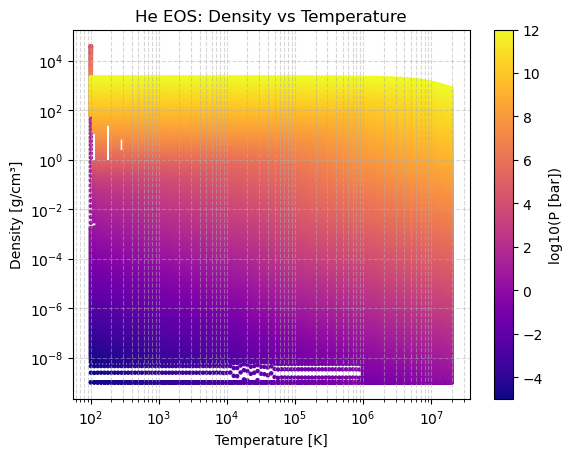

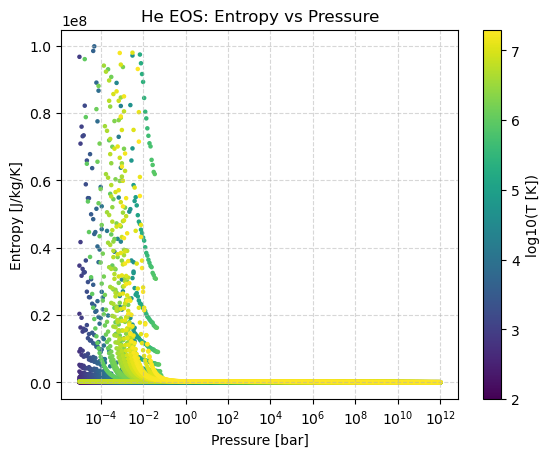

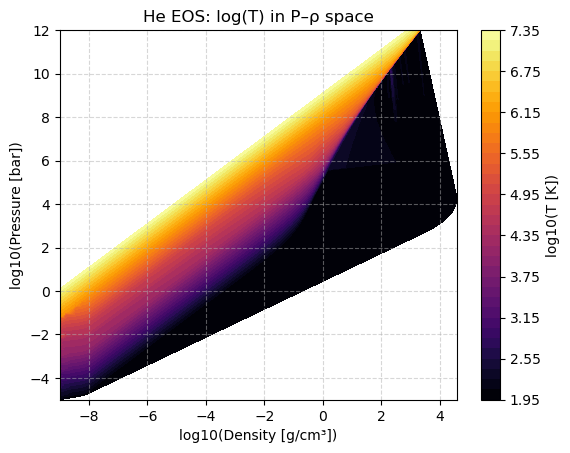

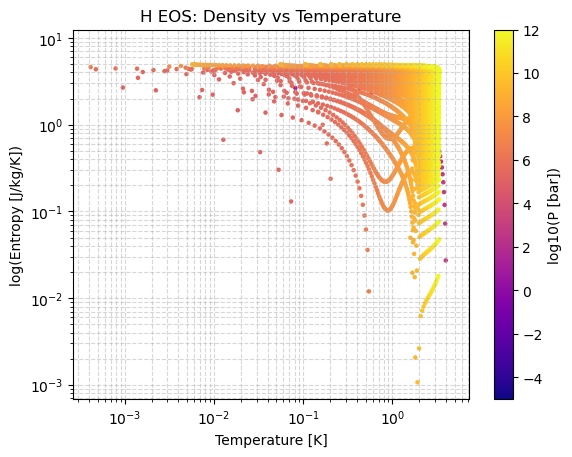

In [19]:
He = load_He_table("./DirTABLES-EOS2019/TABLE_HE_TP_v1")

# Extract columns
T = He[:, T_COL_IDX]
P = He[:, P_COL_IDX]
rho = He[:, RHO_COL_IDX]
S = He[:, S_COL_IDX]

# Log versions for plots
logT = np.log10(T)
logP = np.log10(P)
logRho = np.log10(rho)
logS = np.log10(S)

# 1. Density vs Temperature
plt.figure()
plt.scatter(T, rho, c=np.log10(P), cmap='plasma', s=5)
plt.colorbar(label='log10(P [bar])')
plt.xlabel('Temperature [K]')
plt.ylabel('Density [g/cm³]')
plt.title('He EOS: Density vs Temperature')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which='both', ls='--', alpha=0.5)

# 2. Entropy vs Pressure
plt.figure()
plt.scatter(P, S, c=np.log10(T), cmap='viridis', s=5)
plt.colorbar(label='log10(T [K])')
plt.xlabel('Pressure [bar]')
plt.ylabel('Entropy [J/kg/K]')
plt.title('He EOS: Entropy vs Pressure')
plt.xscale('log')
plt.grid(True, which='both', ls='--', alpha=0.5)

# 3. P–rho isotherms (contour-style)
import matplotlib.tri as tri

plt.figure()
triang = tri.Triangulation(logRho, logP)
plt.tricontourf(triang, logT, levels=50, cmap='inferno')
plt.colorbar(label='log10(T [K])')
plt.xlabel('log10(Density [g/cm³])')
plt.ylabel('log10(Pressure [bar])')
plt.title('He EOS: log(T) in P–ρ space')
plt.grid(True, which='both', ls='--', alpha=0.5)

plt.figure()
plt.scatter(logRho, logS, c=np.log10(P), cmap='plasma', s=5)
plt.colorbar(label='log10(P [bar])')
plt.xlabel('Density [g/cm³]')
plt.ylabel('log(Entropy [J/kg/K])')
plt.title('H EOS: Density vs Temperature')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which='both', ls='--', alpha=0.5)

plt.show()

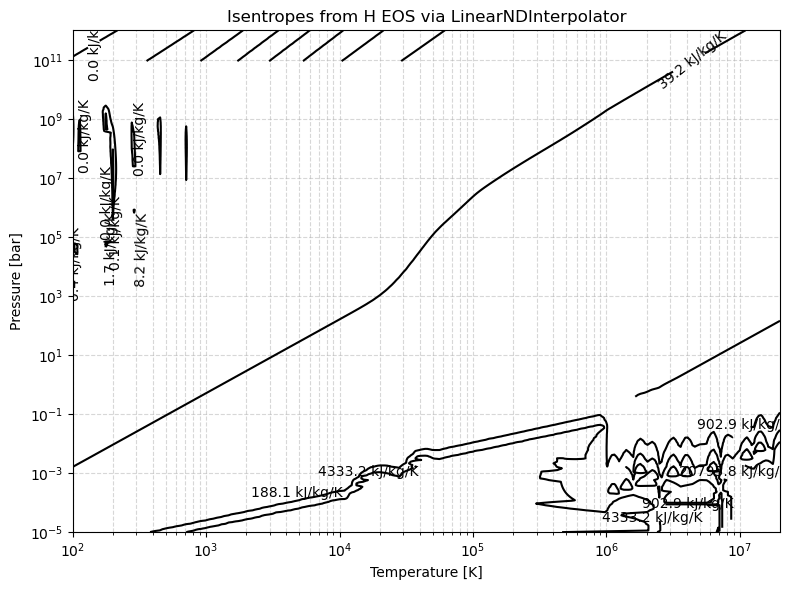

In [18]:
from scipy.interpolate import griddata
from scipy.interpolate import LinearNDInterpolator

# Extract raw data
T = He[:, T_COL_IDX]
P = He[:, P_COL_IDX]
S = He[:, S_COL_IDX]

# Convert to log10-space for stable interpolation
logT = np.log10(T)
logP = np.log10(P)

# Create interpolator: S(logT, logP)
interp_func = LinearNDInterpolator(list(zip(logT, logP)), S)

# Create a regular grid in logT/logP space
logT_grid = np.linspace(logT.min(), logT.max(), 300)
logP_grid = np.linspace(logP.min(), logP.max(), 300)
TT, PP = np.meshgrid(logT_grid, logP_grid)

# Interpolate S values on the grid
S_grid = interp_func(TT, PP)

# Select 10 isentropes in log-space
logS_min, logS_max = np.log10(np.nanmin(S)), np.log10(np.nanmax(S))
logS_levels = np.linspace(logS_min, logS_max, 20)
S_levels = 10**logS_levels  # Convert back to linear space


# Plot
plt.figure(figsize=(8, 6))
cs = plt.contour(10**TT, 10**PP, S_grid, levels=S_levels, colors='k')
plt.clabel(cs, inline=1, fontsize=10, fmt=lambda s: f'{s/1000:.1f} kJ/kg/K')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Temperature [K]')
plt.ylabel('Pressure [bar]')
plt.title('Isentropes from H EOS via LinearNDInterpolator')
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [13]:
np.min(He[:, S_COL_IDX])

np.float64(1.1402497875611696e-05)